<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan4_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF 401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Setup tema visual
sns.set_theme(style='whitegrid', palette='muted')

In [4]:
# 1. MEMUAT DATASET & EKSPLORASI AWAL
print("=== LANGKAH 1: EKSPLORASI AWAL ===")
df = sns.load_dataset('iris')

print(f"1. Shape Dataset: {df.shape}")
print("\n2. Tipe Data (dtypes):")
print(df.dtypes)

print("\n3. Lima Baris Pertama (head):")
display(df.head())

print("\n4. Deskripsi Statistik Dasar (describe):")
display(df.describe())
print("-" * 60)

=== LANGKAH 1: EKSPLORASI AWAL ===
1. Shape Dataset: (150, 5)

2. Tipe Data (dtypes):
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

3. Lima Baris Pertama (head):


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



4. Deskripsi Statistik Dasar (describe):


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


------------------------------------------------------------


In [5]:
# 2. STATISTIK DESKRIPTIF LENGKAP
print("\n=== LANGKAH 2: STATISTIK LANJUTAN ===")
# Mengambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number])

# Menghitung statistik lanjutan
stats_df = pd.DataFrame({
    'Mean': numeric_cols.mean(),
    'Median': numeric_cols.median(),
    'Std Dev': numeric_cols.std(),
    'Variance': numeric_cols.var(),
    'Skewness': numeric_cols.skew(),
    'Kurtosis': numeric_cols.kurtosis()
})
display(stats_df)
print("-" * 60)


=== LANGKAH 2: STATISTIK LANJUTAN ===


,Mean,Median,Std Dev,Variance,Skewness,Kurtosis
sepal_length,5.843333,5.80,0.828066,0.685694,0.314911,-0.552064
sepal_width,3.057333,3.00,0.435866,0.189979,0.318966,0.228249
petal_length,3.758000,4.35,1.765298,3.116278,-0.274884,-1.402103
petal_width,1.199333,1.30,0.762238,0.581006,-0.102967,-1.340604


------------------------------------------------------------


Interpretasi Langkah 1 & 2: Eksplorasi & Statistik Dasar

1.   What?: Dataset memiliki 150 baris dan 5 kolom tanpa ada data kosong (bersih). Dari tabel statistik Langkah 2, nilai Skewness dan Kurtosis bervariasi. Nilai skewness petal_length (0.27) dan petal_width (-0.10) mendekati 0.
2.   So what?: Data ini sudah berada dalam kondisi yang sangat ideal untuk dianalisis tanpa perlu melalui proses pembersihan data (data cleaning) yang rumit.
3.   Now what?: Kita bisa langsung melangkah ke analisis distribusi tunggal (univariate analysis) untuk membedah bentuk data masing-masing kolom.



=== LANGKAH 3: DISTRIBUSI SEPAL LENGTH ===


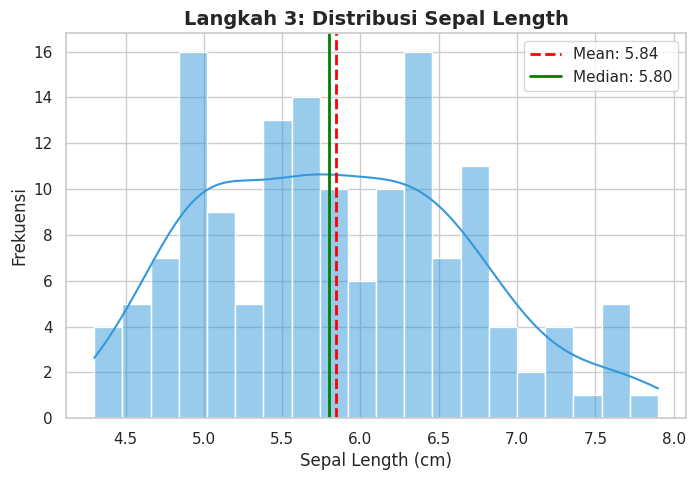

-> Identifikasi: Karena Mean dan Median hampir berhimpitan dan kurva berbentuk lonceng, distribusinya mendekati NORMAL.
------------------------------------------------------------


In [6]:
# 3. HISTOGRAM & KDE (SEPAL LENGTH)
print("\n=== LANGKAH 3: DISTRIBUSI SEPAL LENGTH ===")
mean_sl = df['sepal_length'].mean()
median_sl = df['sepal_length'].median()

plt.figure(figsize=(8, 5))
sns.histplot(df['sepal_length'], kde=True, bins=20, color='#3498db')
plt.axvline(mean_sl, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sl:.2f}')
plt.axvline(median_sl, color='green', linestyle='-', linewidth=2, label=f'Median: {median_sl:.2f}')

plt.title('Langkah 3: Distribusi Sepal Length', fontweight='bold', fontsize=14)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()
print("-> Identifikasi: Karena Mean dan Median hampir berhimpitan dan kurva berbentuk lonceng, distribusinya mendekati NORMAL.")
print("-" * 60)

Interpretasi Langkah 3: Distribusi Sepal Length

1.   What?: Pada grafik Histogram dan kurva KDE, garis Mean (5.84 cm) dan Median (5.80 cm) berada di posisi yang hampir berhimpitan di tengah-tengah puncak kurva yang berbentuk mirip lonceng.
2.   So what?: Bentuk lonceng simetris dengan letak rata-rata dan nilai tengah yang sejajar ini membuktikan bahwa kolom sepal_length memiliki Distribusi Normal.
3.  Now what?: Karena distribusinya normal, kita bisa menerapkan metode statistik parametrik standar ke depannya, seperti T-Test atau Z-score untuk mencari anomali/outlier jika diperlukan.



=== LANGKAH 4: DISTRIBUSI PETAL LENGTH PER SPESIES ===


/tmp/ipykernel_3971/1232724084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')


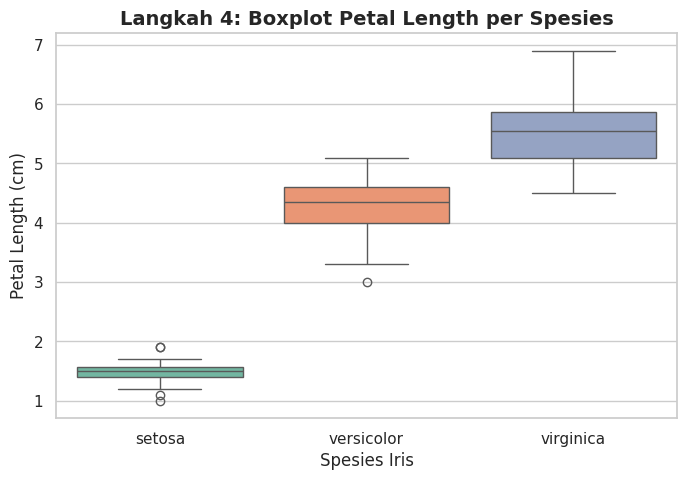

-> Spesies nilai Petal Length TERBESAR   : Virginica
-> Spesies nilai Petal Length TERKECIL   : Setosa
-> Spesies sebaran data PALING TERSEBAR  : Virginica (std tertinggi)
------------------------------------------------------------


In [7]:
# 4.  BOXPLOT PETAL LENGTH PER SPESIES
print("\n=== LANGKAH 4: DISTRIBUSI PETAL LENGTH PER SPESIES ===")
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')
plt.title('Langkah 4: Boxplot Petal Length per Spesies', fontweight='bold', fontsize=14)
plt.xlabel('Spesies Iris')
plt.ylabel('Petal Length (cm)')
plt.show()

# Analisis Otomatis
terbesar = df.groupby('species')['petal_length'].max().idxmax()
terkecil = df.groupby('species')['petal_length'].min().idxmin()
tersebar = df.groupby('species')['petal_length'].std().idxmax()

print(f"-> Spesies nilai Petal Length TERBESAR   : {terbesar.capitalize()}")
print(f"-> Spesies nilai Petal Length TERKECIL   : {terkecil.capitalize()}")
print(f"-> Spesies sebaran data PALING TERSEBAR  : {tersebar.capitalize()} (std tertinggi)")
print("-" * 60)

Interpretasi Langkah 4: Boxplot Petal Length per Spesies
1.   What?: Boxplot mendeteksi pemisahan yang sangat tegas. Setosa memiliki rentang petal_length paling kecil dan terkumpul rapat, Virginica memiliki nilai maksimal terbesar, sedangkan Versicolor merupakan spesies dengan variasi ukuran (simpangan baku/std) paling tersebar.
2.   So what?: Karakteristik fisik kelopak (petal) adalah parameter biologi utama yang paling efektif untuk membedakan identitas setiap spesies bunga Iris secara kasatmata.
3.   Now what?: Fitur petal_length wajib diprioritaskan (menjadi fitur utama) jika kita ingin membuat model Machine Learning untuk mengklasifikasi jenis spesies Iris secara otomatis.

In [8]:
# 5. MATRIKS KORELASI
print("\n=== LANGKAH 5: MATRIKS KORELASI ===")
corr = numeric_cols.corr()
display(corr)

# Filter diagonal (nilai 1.0) untuk mencari korelasi antar fitur yang berbeda
corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

# Korelasi tertinggi (mendekati 1 atau -1)
max_corr_idx = corr_unstacked.idxmax()
max_corr_val = corr_unstacked.max()

# Korelasi terendah (paling mendekati 0 / tidak ada hubungan)
min_corr_idx = corr_unstacked.abs().idxmin()
min_corr_val = corr_unstacked[min_corr_idx]

print(f"-> Pasangan Korelasi TERTINGGI: {max_corr_idx[0]} & {max_corr_idx[1]} ({max_corr_val:.3f})")
print(f"-> Pasangan Korelasi TERENDAH : {min_corr_idx[0]} & {min_corr_idx[1]} ({min_corr_val:.3f})")
print("-" * 60)


=== LANGKAH 5: MATRIKS KORELASI ===


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


-> Pasangan Korelasi TERTINGGI: petal_length & petal_width (0.963)
-> Pasangan Korelasi TERENDAH : sepal_length & sepal_width (-0.118)
------------------------------------------------------------



=== LANGKAH 6: VISUALISASI KORELASI TERTINGGI ===


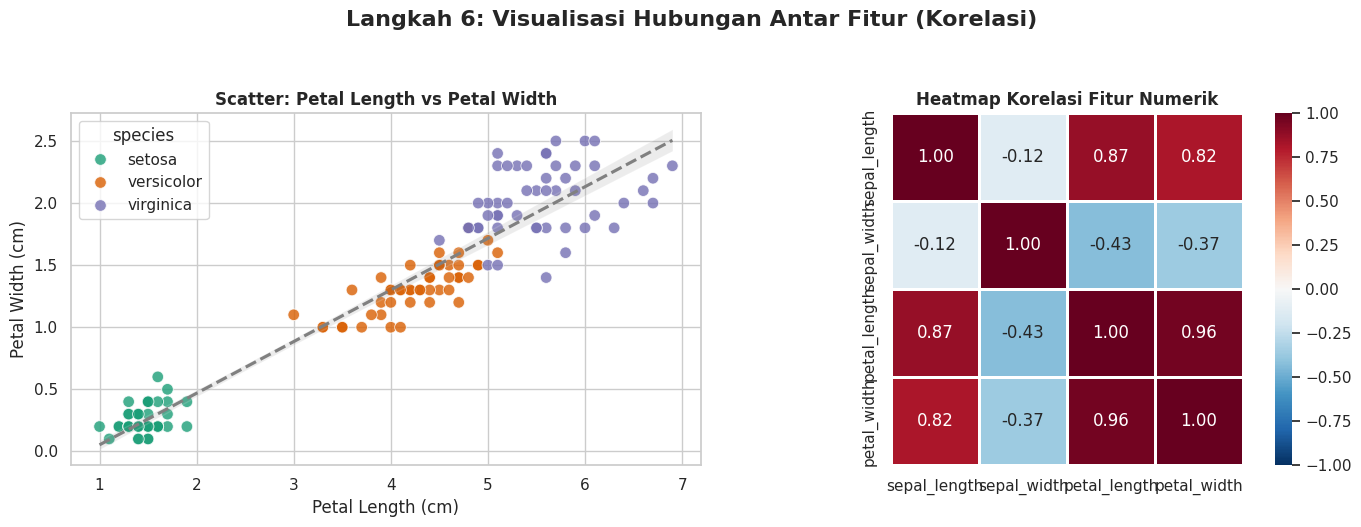

In [9]:
# 6. SCATTER PLOT & HEATMAP ─────────────────────────────────
print("\n=== LANGKAH 6: VISUALISASI KORELASI TERTINGGI ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter Plot (Pasangan tertinggi)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Dark2', s=70, alpha=0.8, ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', line_kws={'linestyle':'--'}, ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width', fontweight='bold')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Plot 2: Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, linewidths=1, ax=axes[1])
axes[1].set_title('Heatmap Korelasi Fitur Numerik', fontweight='bold')

plt.suptitle('Langkah 6: Visualisasi Hubungan Antar Fitur (Korelasi)', fontweight='bold', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Interpretasi Langkah 5 & 6: Korelasi (Scatter & Heatmap)
1.   What?: Matriks korelasi dan Heatmap menunjukkan bahwa pasangan Petal Length & Petal Width memiliki korelasi positif yang sangat kuat ($0.963$). Sebaliknya, pasangan Sepal Length & Sepal Width nyaris tidak ada hubungannya ($-0.118$). Scatter plot juga memperlihatkan bahwa semakin panjang petal, semakin lebar pula petal tersebut, dan titik-titiknya secara alami membentuk 3 kelompok spesies yang terpisah dengan rapi.
2.   So what?: Terjadinya hubungan 0.96 ini disebut dengan gejala Multikolinearitas (dua fitur menyampaikan informasi yang nyaris sama). Selain itu, perbedaan ukuran ini secara harfiah menegaskan evolusi anatomi dari ketiga spesies (Setosa berukuran mini, Virginica berukuran jumbo).
3.   Now what?: Jika digunakan untuk Machine Learning (seperti Logistic Regression), kita bisa membuang salah satu dari petal_length atau petal_width guna menyederhanakan komputasi model, karena satu ukuran kelopak sudah cukup mewakili informasi ukuran kelopak lainnya.
